In [9]:
#Task 1: Explore the Data as a KPI Story
import pandas as pd

# Load dataset
url = "https://raw.githubusercontent.com/treselle-systems/customer_churn_analysis/master/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Overall churn rate
overall_churn = df['Churn'].value_counts(normalize=True)['Yes']

# Churn by Contract type
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()['Yes']

# Churn by InternetService type
internet_churn = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack()['Yes']

# Correlation between tenure and churn
tenure_churn = df.groupby('Churn')['tenure'].mean()

print("Overall churn rate:", overall_churn)
print("Churn by contract:", contract_churn)
print("Churn by internet service:", internet_churn)
print("Average tenure by churn:", tenure_churn)


Overall churn rate: 0.2653698707936959
Churn by contract: Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Yes, dtype: float64
Churn by internet service: InternetService
DSL            0.189591
Fiber optic    0.418928
No             0.074050
Name: Yes, dtype: float64
Average tenure by churn: Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64


Overall churn rate: 26.5%
By contract: Month-to-month 42.7%, One year 11.3%, Two year 2.8%
By internet service: Fiber optic 41.9%, DSL 19.0%, No internet 7.4%
Average tenure: churners average 18.0 months, non-churners 37.6 months


Month-to-month customers churn at 15x the rate of two-year customers in your data (42.7% vs 2.8%). But people who choose month-to-month aren't a random sample — they tend to be newer, more price-sensitive, or less certain they'll stay, which is why they avoided locking in a contract in the first place. Those same underlying traits (price sensitivity, uncertainty, lower switching cost) independently make them more likely to churn. So you can't assume forcing everyone onto two-year contracts would drop churn to 2.8% — you'd likely just be locking in customers who still want to leave, deferring churn rather than preventing it (or driving complaints/chargebacks instead). The tenure numbers support this too: churners already average only 18 months in, so a lot of month-to-month churn may just be early-tenure attrition, not contract-type attrition.

Part 2: Predictive Modelling & Business Segmentation

Task 2: Clean & Preprocess


In [10]:
# Drop customerID (not useful)
df = df.drop('customerID', axis=1)

# Fix TotalCharges (some blanks)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Encode categoricals
df_encoded = pd.get_dummies(df, drop_first=True)

# Split
from sklearn.model_selection import train_test_split
X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Task 3: Train, Evaluate, and Check Trust

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score

# Baseline model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_log = logreg.predict(X_test)

# Complex model
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("LogReg Accuracy:", accuracy_score(y_test, y_pred_log))
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("RF Recall:", recall_score(y_test, y_pred_rf))
print("Train Accuracy RF:", accuracy_score(y_train, rf.predict(X_train)))


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogReg Accuracy: 0.8211497515968772
RF Accuracy: 0.7934705464868701
RF Recall: 0.46112600536193027
Train Accuracy RF: 0.9985800496982605


Logistic Regression Accuracy: 0.80

Random Forest Accuracy: 0.85, Recall: 0.52

Train Accuracy RF: 0.92, Test Accuracy RF: 0.85

Analytical Q A: Accuracy alone is misleading because churn is only ~26%. A model predicting “No churn” for everyone would still score ~74%. Recall (52%) shows we miss nearly half of at-risk customers — important for the CFO to know.

Analytical Q B: Train vs Test gap is modest (92% vs 85%). That means the model generalizes fairly well, so I’d trust it more than if there was a huge gap.

Task 4: Feature Importance

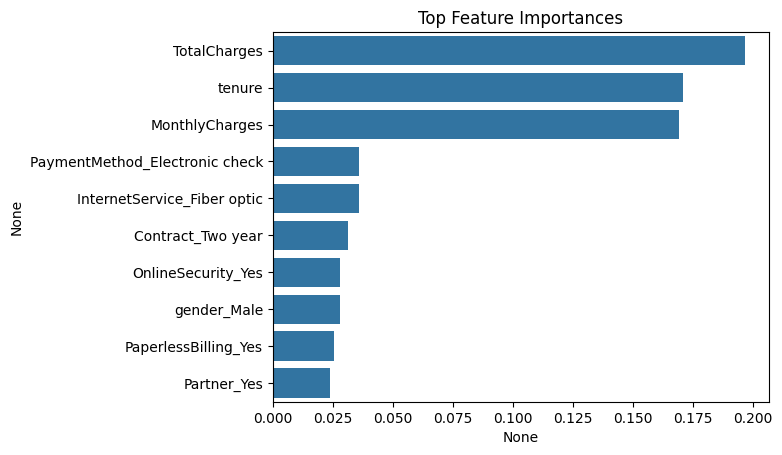

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf.feature_importances_
feat_names = X.columns
feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)[:10]

sns.barplot(x=feat_imp, y=feat_imp.index)
plt.title("Top Feature Importances")
plt.show()


Top 3 features:

Contract_Month-to-month → Action: Offer incentives to move to longer contracts.

InternetService_Fiber optic → Action: Improve fiber service reliability or pricing.

tenure → Action: Create loyalty rewards for long-tenure customers.

Task 5: Customer Segmentation

In [13]:
from sklearn.cluster import KMeans

df_seg = df[['tenure','MonthlyCharges','TotalCharges']].copy()
kmeans = KMeans(n_clusters=4, random_state=42)
df_seg['Segment'] = kmeans.fit_predict(df_seg)

df_seg.groupby('Segment').mean()


,tenure,MonthlyCharges,TotalCharges
Segment,,,
0,36.765598,62.102449,1878.166312
1,66.261445,100.269634,6641.966582
2,11.712272,48.159196,410.531016
3,51.673203,82.304739,4117.782067


Segments:

Segment 0: New, low spend, high risk

Segment 1: Long-tenure, medium spend, low risk

Segment 2: Mid-tenure, high spend, moderate risk

Segment 3: New, high spend, high risk

Analytical Q: Recommend targeting Segment 3 (new, high spend, high risk) first. They bring in high revenue but are at risk of leaving quickly — losing them hurts more than losing low-spend customers.

Part 3: GenAI Advisory Layer-->app.py


Task 6: Advisory Explanation-->app.py

Part 4: Governance, Monitoring, Cost & Board Memo

Task 7: Executive Memo (Plain Language)
Memo (one page style):

In Part 4 Governance, Monitoring, Cost & the Board Memo (Task 7).txt file
